In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression



In [6]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
roc_curve,
auc
)

In [11]:
data=load_breast_cancer()

X=data.data
y=data.target

print("Dataset Shape:",X.shape)
print("Classes:",np.unique(y))

Dataset Shape: (569, 30)
Classes: [0 1]


In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [16]:
mle_model=LogisticRegression(
    penalty=None,
    max_iter=5000,
    random_state=42
)

mle_model.fit(X_train,y_train)

y_pred_mle=mle_model.predict(X_test)

In [17]:
map_l2=LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',

    max_iter=5000,
    random_state=42
)
map_l2.fit(X_train,y_train)
y_pred_l2=map_l2.predict(X_test)

In [21]:
map_l1=LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=5000,
    random_state=42
)
map_l1.fit(X_train,y_train)
y_pred_l1=map_l1.predict(X_test)


In [38]:
def evaluate(model_name,y_true,y_pred) :

    print("\n","="*40)
    print(model_name)
    print("="*40)

    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("Precision :",precision_score(y_true,y_pred))
    print("Recall :",recall_score(y_true,y_pred))
    print("F1 Score :",f1_score(y_true,y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true,y_pred))

In [39]:
evaluate ("MLE",y_test,y_pred_mle)
evaluate ("MAP(L2)",y_test,y_pred_l2)
evaluate ("MAP(L1)",y_test,y_pred_l1)


MLE
Accuracy : 0.9210526315789473
Precision : 0.9701492537313433
Recall : 0.9027777777777778
F1 Score : 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]

MAP(L2)
Accuracy : 0.9824561403508771
Precision : 0.9861111111111112
Recall : 0.9861111111111112
F1 Score : 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]

MAP(L1)
Accuracy : 0.9912280701754386
Precision : 0.9863013698630136
Recall : 1.0
F1 Score : 0.993103448275862

Confusion Matrix
[[41  1]
 [ 0 72]]


In [28]:
print("Number of Zero Coefficients")
print("MLE :",np.sum(mle_model.coef_[0]==0))
print("MAP L2 :",np.sum(map_l2.coef_[0]==0))
print("MAP L1 :",np.sum(map_l1.coef_[0]==0))

Number of Zero Coefficients
MLE : 0
MAP L2 : 0
MAP L1 : 14


In [62]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])
models = [
    ("MLE",mle_model,y_pred_mle),
    ("MAP L2",map_l2,y_pred_l2),
    ("MAP L1",map_l1,y_pred_l1)
]

for name,model,pred in models: 
    results.loc[len(results)] = [
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ]
print(results)   

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


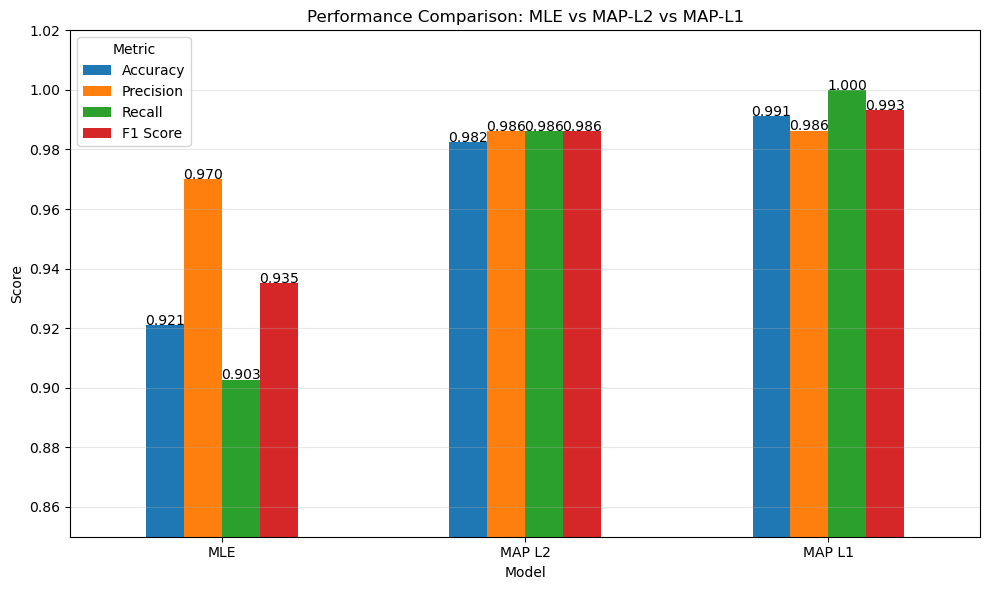

In [63]:
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison: MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

# Show values on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=-2)

plt.tight_layout()
plt.show()

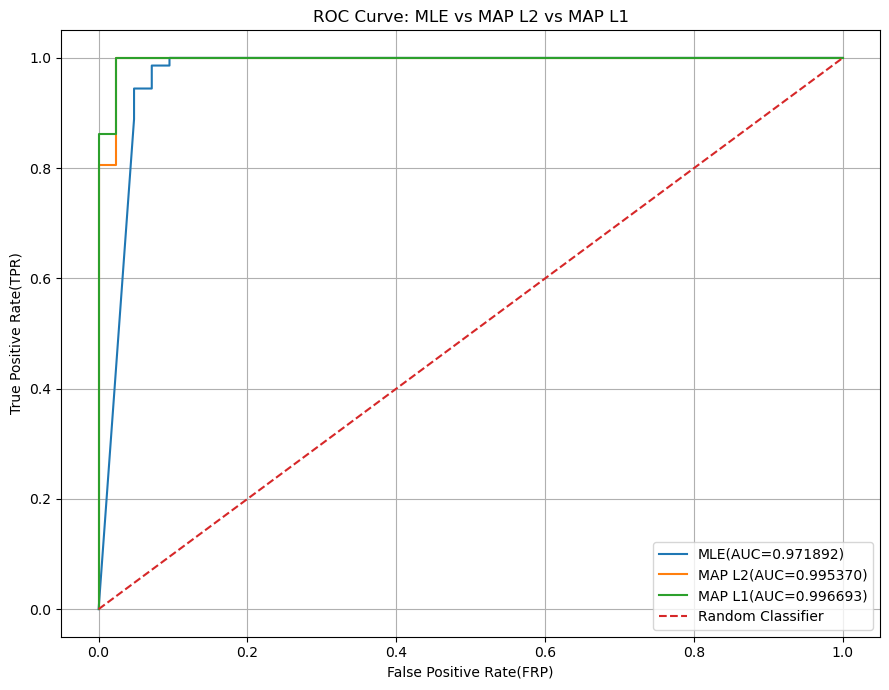

In [64]:
plt.figure(figsize=(9,7))
for name, model, pred in models:
    #Predicted probability for positive class

    y_prob=model.predict_proba(X_test)[:,1] #Gives the probability of each class

    #Calculate ROC values
    fpr,tpr,thresholds=roc_curve(y_test,y_prob)
    #Calculate AUC
    roc_auc=auc(fpr,tpr)
    #Plot ROC Curve
    plt.plot(
    fpr,
    tpr,
    label=f"{name}(AUC={roc_auc:3f})"
    )
    # Random classifier reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)
#Zoom into the useful region
#plt.xlim(0,0.15)                # For Zooming in remove the '#' in both lines
#plt.ylim(0.75,1.01)
plt.xlabel("False Positive Rate(FRP)")
plt.ylabel("True Positive Rate(TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


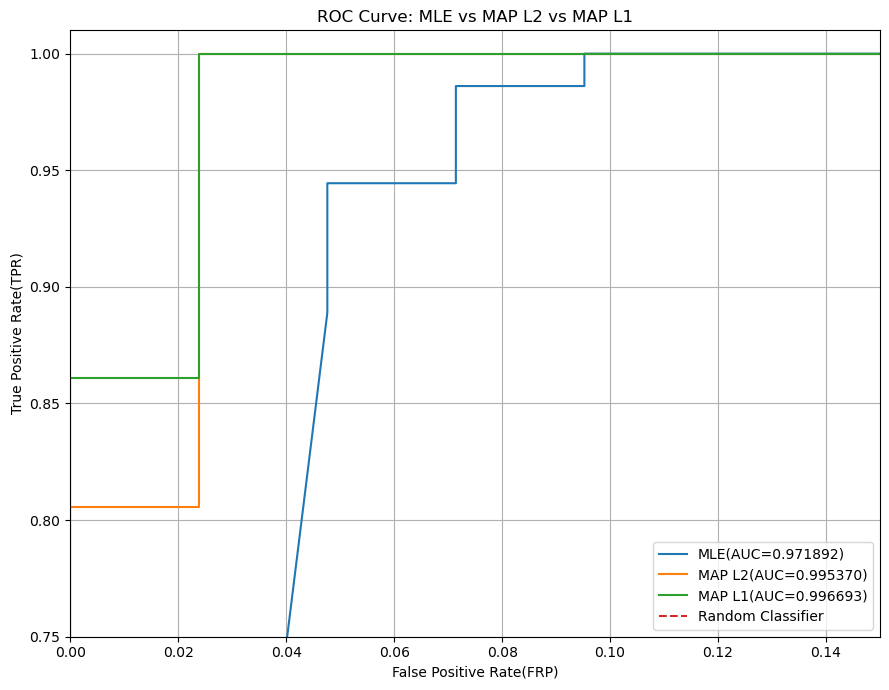

In [65]:
plt.figure(figsize=(9,7))
for name, model, pred in models:
    #Predicted probability for positive class

    y_prob=model.predict_proba(X_test)[:,1] #Gives the probability of each class

    #Calculate ROC values
    fpr,tpr,thresholds=roc_curve(y_test,y_prob)
    #Calculate AUC
    roc_auc=auc(fpr,tpr)
    #Plot ROC Curve
    plt.plot(
    fpr,
    tpr,
    label=f"{name}(AUC={roc_auc:3f})"
    )
    # Random classifier reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)
#Zoom into the useful region
plt.xlim(0,0.15)                # For ZoomOut  in add the '#' 
plt.ylim(0.75,1.01)             # For ZoomOut  in add the '#' 
plt.xlabel("False Positive Rate(FRP)")
plt.ylabel("True Positive Rate(TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()